In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
import pickle
import sklearn
import os

In [2]:
import nltk
from nltk.stem import WordNetLemmatizer
import re
from nltk.corpus import wordnet

In [3]:
#nltk.download("wordnet")
#nltk.download("omw-1.4")
#nltk.download("punkt")

In [4]:
all_data = pd.read_csv("data/Reviews.csv",engine="python")

In [5]:
all_data = all_data[all_data["Score"].isin([1, 3, 5])]

In [6]:
sentiment_mapping = {
    1: "bad",
    3: "neutral",
    5: "good",
}

In [7]:
all_data["Score"] = all_data["Score"].map(sentiment_mapping)

In [8]:
all_data.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,good,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,bad,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,good,1350777600,Great taffy,Great taffy at a great price. There was a wid...
6,7,B006K2ZZ7K,A1SP2KVKFXXRU1,David C. Sullivan,0,0,good,1340150400,Great! Just as good as the expensive brands!,This saltwater taffy had great flavors and was...
7,8,B006K2ZZ7K,A3JRGQVEQN31IQ,Pamela G. Williams,0,0,good,1336003200,"Wonderful, tasty taffy",This taffy is so good. It is very soft and ch...


In [9]:
df = all_data[["Score", "Text"]].copy()

In [10]:
df.head()

,Score,Text
0,good,I have bought several of the Vitality canned d...
1,bad,Product arrived labeled as Jumbo Salted Peanut...
4,good,Great taffy at a great price. There was a wid...
6,good,This saltwater taffy had great flavors and was...
7,good,This taffy is so good. It is very soft and ch...


In [11]:
df.isna().sum()

Score    0
Text     0
dtype: int64

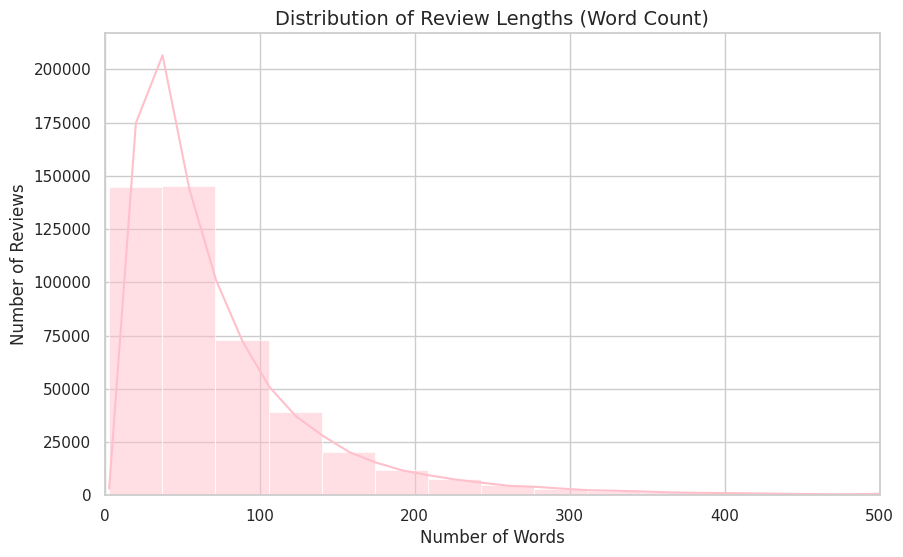

In [12]:
sns.set_theme(style="whitegrid")

text_lengths = df['Text'].dropna().apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))

sns.histplot(text_lengths, bins=100, color="pink", kde=True) 


plt.xlim(0, 500)

plt.title("Distribution of Review Lengths (Word Count)", fontsize=14)
plt.xlabel("Number of Words", fontsize=12)
plt.ylabel("Number of Reviews", fontsize=12)

plt.show()

In [13]:
text_lengths = df['Text'].dropna().apply(lambda x: len(str(x).split()))

print(text_lengths.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

count    458030.000000
mean         77.668849
std          77.801145
min           3.000000
50%          54.000000
75%          94.000000
90%         155.000000
95%         211.000000
99%         380.710000
max        3432.000000
Name: Text, dtype: float64


In [14]:
df['word_count'] = df['Text'].apply(lambda x: len(str(x).split()))

print(df.groupby('Score')['word_count'].describe())

            count       mean        std  min   25%   50%    75%     max
Score                                                                  
bad       52268.0  87.323697  93.147838  3.0  37.0  62.0  104.0  2149.0
good     363122.0  74.168167  73.354262  3.0  32.0  52.0   89.0  2520.0
neutral   42640.0  95.645755  89.553989  7.0  40.0  70.0  121.0  3432.0


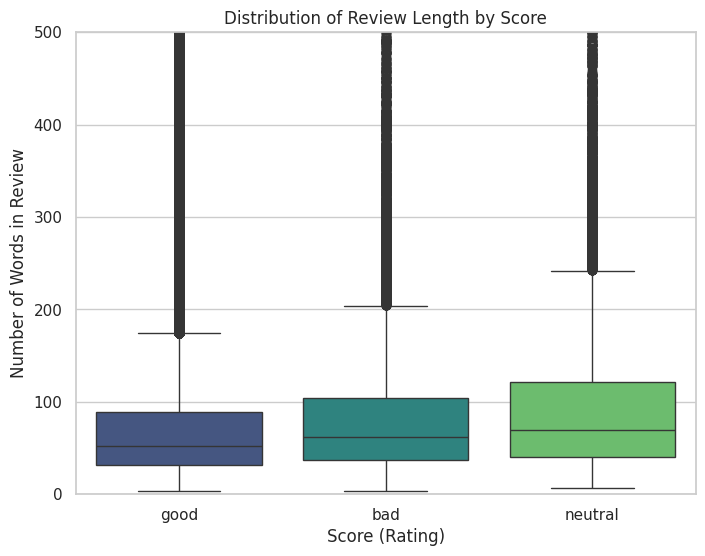

In [15]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 6))
sns.boxplot(x="Score", y="word_count", data=df, hue="Score", palette="viridis", legend=False)

plt.ylim(0, 500)

plt.title("Distribution of Review Length by Score")
plt.xlabel("Score (Rating)")
plt.ylabel("Number of Words in Review")
plt.show()

In [16]:
print(f"Number of reviews before filtering: {len(df)}")

Number of reviews before filtering: 458030


In [17]:
df = df[df['Text'].apply(lambda x: len(str(x).split()) <= 50)]

print(f"Number of reviews after filtering (<= 50 words): {len(df)}")

Number of reviews after filtering (<= 50 words): 212450


In [18]:
class_counts = df['Score'].value_counts().sort_index()
print("Number of reviews per class:")
print(class_counts)

Number of reviews per class:
Score
bad         20549
good       177147
neutral     14754
Name: count, dtype: int64


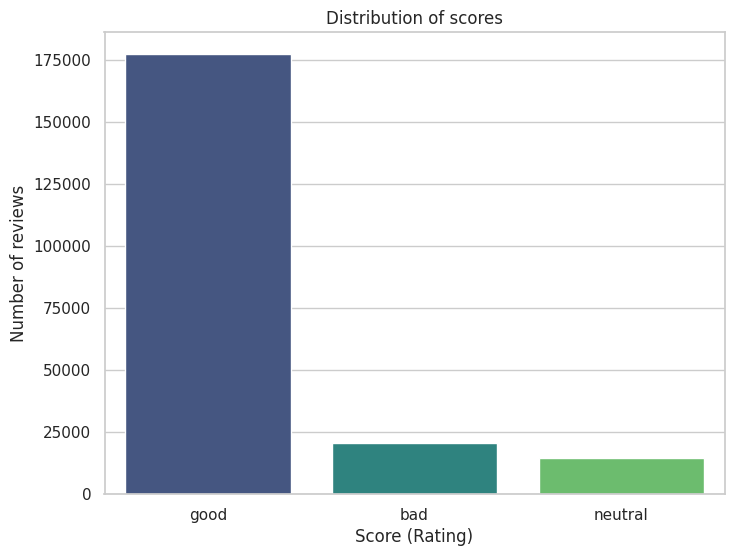

In [19]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 6))
sns.countplot(x="Score", data=df, hue="Score", palette="viridis", legend=False)

plt.title("Distribution of scores")
plt.xlabel("Score (Rating)")
plt.ylabel("Number of reviews")
plt.show()

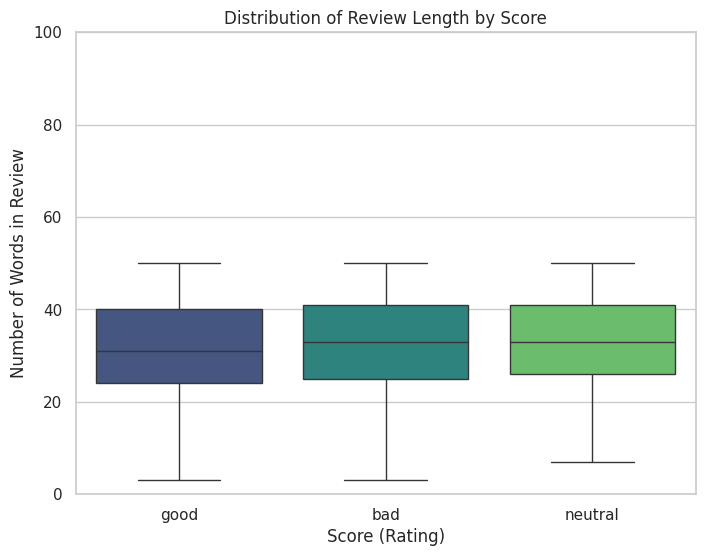

In [20]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 6))
sns.boxplot(x="Score", y="word_count", data=df, hue="Score", palette="viridis", legend=False)

plt.ylim(0, 100)

plt.title("Distribution of Review Length by Score")
plt.xlabel("Score (Rating)")
plt.ylabel("Number of Words in Review")
plt.show()

In [21]:
df = df.drop(columns=['word_count'])

In [22]:
rest_df, test_df = sklearn.model_selection.train_test_split(df,test_size=5000,random_state=42, stratify=df['Score'])

In [23]:
train_full_df, val_df = sklearn.model_selection.train_test_split(rest_df, test_size=5000, random_state=42, stratify=rest_df['Score'])

In [24]:
# Creating two training sets: balanced and with the original distribution

In [25]:
target_count = 13333
train_balanced = pd.concat([
    train_full_df[train_full_df['Score'] == 'good'].sample(n=target_count, random_state=42),
    train_full_df[train_full_df['Score'] == 'bad'].sample(n=target_count, random_state=42),
    train_full_df[train_full_df['Score'] == 'neutral'].sample(n=target_count, random_state=42)
])
train_balanced = train_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

In [26]:
_, train_imbalanced = sklearn.model_selection.train_test_split(train_full_df, test_size=40000, random_state=42, stratify=train_full_df['Score'])
train_imbalanced = train_imbalanced.reset_index(drop=True)

In [27]:
print(f"Test dataset: {len(test_df)}")
print(f"Validation dataset: {len(val_df)}")

print("Balanced train dataset")
print(train_balanced['Score'].value_counts())

print("Imbalanced train dataset");
print(train_imbalanced['Score'].value_counts())

Test dataset: 5000
Validation dataset: 5000
Balanced train dataset
Score
good       13333
bad        13333
neutral    13333
Name: count, dtype: int64
Imbalanced train dataset
Score
good       33353
bad         3869
neutral     2778
Name: count, dtype: int64


In [28]:
lemmatizer = WordNetLemmatizer()

In [29]:
def get_wordnet_pos(word):
  tag = nltk.pos_tag([word])[0][1].upper()
  if tag.startswith("J") or tag.startswith("S"):
    return wordnet.ADJ
  elif tag.startswith("V"):
    return wordnet.VERB
  elif tag.startswith("N"):
    return wordnet.NOUN
  elif tag.startswith("R"):
    return wordnet.ADV
  else:
    return wordnet.NOUN  

In [30]:
def lemmatize_text(text):
    
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    words = text.split()

    lemmatized_words = [lemmatizer.lemmatize(word, pos=get_wordnet_pos(word)) for word in words]
    return " ".join(lemmatized_words)    

In [ ]:
train_balanced["Cleaned_Text"] = train_balanced["Text"].apply(lemmatize_text)
train_imbalanced["Cleaned_Text"] = train_imbalanced["Text"].apply(lemmatize_text)
val_df["Cleaned_Text"] = val_df["Text"].apply(lemmatize_text)
test_df["Cleaned_Text"] = test_df["Text"].apply(lemmatize_text)

In [ ]:
os.makedirs("data", exist_ok=True)

In [ ]:
train_balanced.to_csv("data/train_balanced.csv", index=False)
train_imbalanced.to_csv("data/train_imbalanced.csv", index=False)
val_df.to_csv("data/validation_df.csv", index=False)
test_df.to_csv("data/test_df.csv", index=False)

In [ ]:
custom_stop_words = list(sklearn.feature_extraction.text.ENGLISH_STOP_WORDS - {"not", "no", "never", "nor","but"})

In [ ]:
vectorizer = TfidfVectorizer(max_features=10000,stop_words=custom_stop_words, ngram_range=(1,2), lowercase=True)

In [ ]:
X_train_vec = vectorizer.fit_transform(train_balanced["Cleaned_Text"])
y_train = train_balanced["Score"]

In [ ]:
X_val_vec = vectorizer.transform(val_df["Cleaned_Text"])
y_val = val_df["Score"]

In [ ]:
X_test_vec = vectorizer.transform(test_df["Cleaned_Text"])
y_test = test_df["Score"]

In [ ]:
with open("prepared_data.pkl", "wb") as f:
  pickle.dump((X_train_vec, y_train, X_val_vec, y_val, X_test_vec, y_test, vectorizer),f)